In [8]:
import numpy as np
import matplotlib.pyplot as plt

class SpaceMissionEnv:
    def __init__(self):
        self.reset()

    def reset(self):
        self.energy = 100.0
        self.temperature = 20.0
        self.health = 100.0
        return self._get_state()

    def _get_state(self):
        return np.array([
            self.energy / 100,
            self.temperature / 100,
            self.health / 100
        ])

    def step(self, action):


        if action == 0:
            self.energy -= np.random.uniform(0.3, 0.5)
            self.temperature += np.random.uniform(0.1, 0.2)

        elif action == 1:
            self.energy -= np.random.uniform(0.1, 0.2)
            self.temperature -= np.random.uniform(0.05, 0.1)

        elif action == 2:
            self.energy -= np.random.uniform(0.4, 0.6)
            self.temperature -= np.random.uniform(0.2, 0.4)


        if self.temperature > 35:
            self.health -= 1.0
        elif self.temperature < 15:
            self.health -= 0.5
        else:
            self.health += 0.2

        self.energy = np.clip(self.energy, 0, 100)
        self.temperature = np.clip(self.temperature, 0, 100)
        self.health = np.clip(self.health, 0, 100)

        done = self.energy <= 0 or self.health <= 0


        reward = self.health / 100 - self.temperature / 100

        return self._get_state(), reward, done

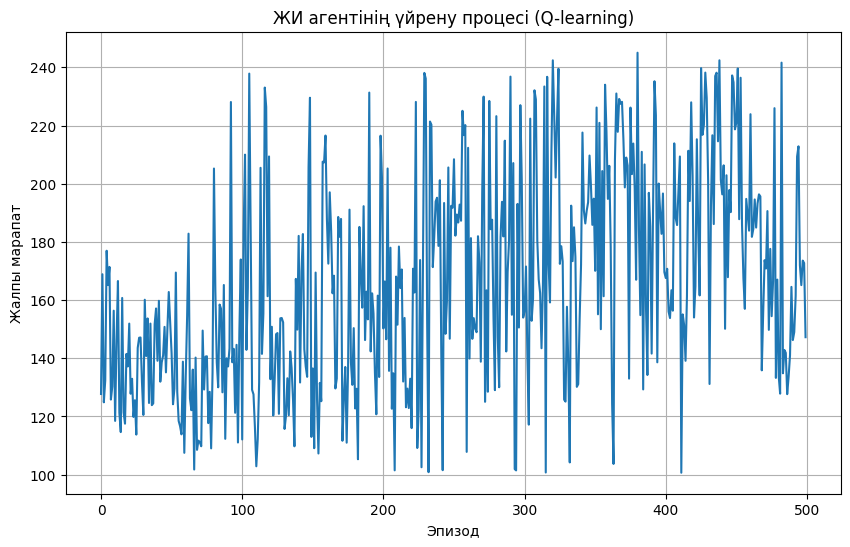

In [9]:


env = SpaceMissionEnv()


q_table = np.zeros((10, 10, 10, 3))

alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

episodes = 500

episode_rewards = []

def discretize(state):
    e = min(int(state[0] * 10), 9)
    t = min(int(state[1] * 10), 9)
    h = min(int(state[2] * 10), 9)
    return e, t, h

for ep in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(300):
        s = discretize(state)

        if np.random.rand() < epsilon:
            action = np.random.randint(3)
        else:
            action = np.argmax(q_table[s])

        next_state, reward, done = env.step(action)
        s_next = discretize(next_state)

        q_table[s + (action,)] += alpha * (
            reward + gamma * np.max(q_table[s_next]) - q_table[s + (action,)]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)
    epsilon = max(epsilon * epsilon_decay, epsilon_min)



plt.figure(figsize=(10,6))
plt.plot(episode_rewards)
plt.xlabel("Эпизод")
plt.ylabel("Жалпы марапат")
plt.title("ЖИ агентінің үйрену процесі (Q-learning)")
plt.grid()
plt.show()

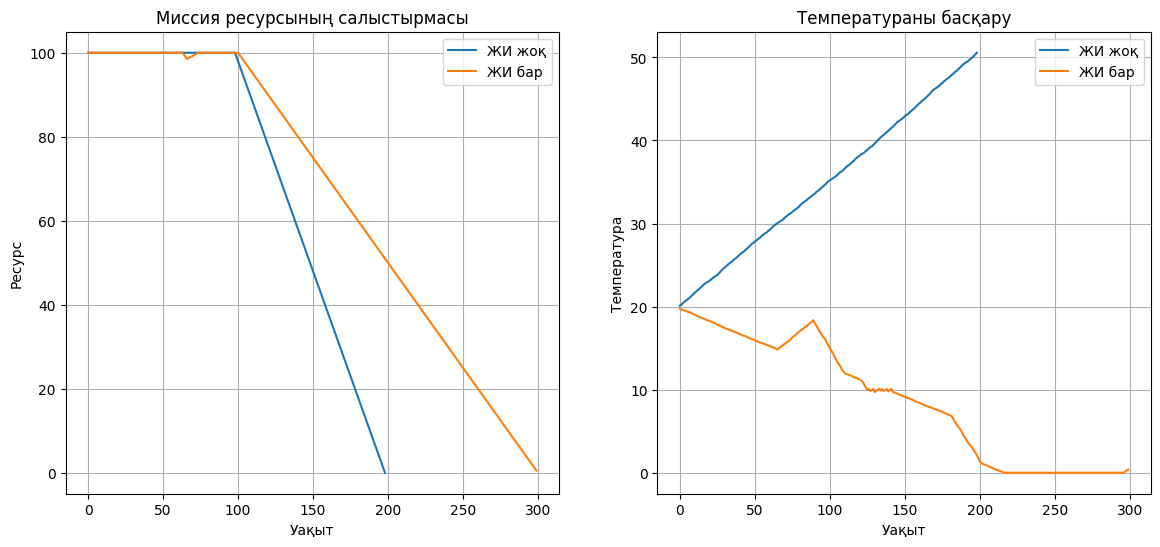

In [10]:

def run_mission(use_ai=True, steps=300):
    env = SpaceMissionEnv()
    state = env.reset()

    energy_log = []
    temp_log = []
    health_log = []

    for _ in range(steps):
        if use_ai:
            s = discretize(state)
            action = np.argmax(q_table[s])
        else:
            action = 0

        state, reward, done = env.step(action)

        energy_log.append(env.energy)
        temp_log.append(env.temperature)
        health_log.append(env.health)

        if done:
            break

    return energy_log, temp_log, health_log




energy_no_ai, temp_no_ai, health_no_ai = run_mission(use_ai=False)
energy_ai, temp_ai, health_ai = run_mission(use_ai=True)




plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(health_no_ai, label="ЖИ жоқ")
plt.plot(health_ai, label="ЖИ бар")
plt.title("Миссия ресурсының салыстырмасы")
plt.xlabel("Уақыт")
plt.ylabel("Ресурс")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(temp_no_ai, label="ЖИ жоқ")
plt.plot(temp_ai, label="ЖИ бар")
plt.title("Температураны басқару")
plt.xlabel("Уақыт")
plt.ylabel("Температура")
plt.legend()
plt.grid()

plt.show()